# Part 2b: Quantization with Brevitas

In this notebook we train the same jet tagger architecture using [**Brevitas**](https://github.com/xilinx/brevitas) — AMD's/Xilinx's PyTorch-native quantization-aware training library — and convert it to an FPGA design via the **QONNX** (Quantized ONNX) frontend of hls4ml.

The workflow in this notebook is:
1. Define a Brevitas model with `QuantLinear` and `QuantReLU` layers and train it
2. Export to QONNX with `export_qonnx`
3. Clean up the QONNX graph and import it into hls4ml via `convert_from_onnx_model`

Make sure you have run `1_getting_started/1b_train_pytorch.ipynb` first so that the data and baseline PyTorch model are available.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('..')
import plotting

%matplotlib inline
seed = 0
np.random.seed(seed)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import brevitas.nn as qnn
from brevitas.export import export_qonnx

torch.manual_seed(seed)

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

/home/enlupi/miniconda3/envs/hls4ml-tutorial-revamp/lib/python3.10/site-packages/brevitas/graph/equalize.py:68: UserWarning: fast_hadamard_transform package not found, using standard pytorch kernels
  warnings.warn("fast_hadamard_transform package not found, using standard pytorch kernels")


## Load the jet tagging dataset

We load the preprocessed arrays saved by `1b_train_pytorch.ipynb`.

In [2]:
X_train_val = np.load('../data/jet-tagging/X_train_val.npy')
X_test = np.load('../data/jet-tagging/X_test.npy')
y_train_val = np.load('../data/jet-tagging/y_train_val.npy')
y_test = np.load('../data/jet-tagging/y_test.npy')
classes = np.load('../data/jet-tagging/classes.npy', allow_pickle=True)

## Define a Brevitas model

Brevitas replaces standard PyTorch layers with quantized equivalents:
- `QuantLinear` — linear layer with quantized weights (and optionally biases)
- `QuantReLU` — ReLU that clips and quantizes activations to a fixed bit-width

We use `weight_bit_width=6` and `bit_width=6` throughout, matching the 6-bit precision from Part 2a.
Unlike regular PyTorch, every forward pass applies the quantization, so the model trains with the actual fixed-point precisions used on the FPGA.

In [3]:
class JetTaggerBrevitas(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = qnn.QuantLinear(16, 64, bias=False, weight_bit_width=6)
        self.relu1 = qnn.QuantReLU(bit_width=6)
        self.fc2 = qnn.QuantLinear(64, 32, bias=False, weight_bit_width=6)
        self.relu2 = qnn.QuantReLU(bit_width=6)
        self.fc3 = qnn.QuantLinear(32, 32, bias=False, weight_bit_width=6)
        self.relu3 = qnn.QuantReLU(bit_width=6)
        self.output = qnn.QuantLinear(32, 5, bias=False, weight_bit_width=6)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.output(x)
        return torch.softmax(x, dim=1)


model = JetTaggerBrevitas()
print(model)

JetTaggerBrevitas(
  (fc1): QuantLinear(
    in_features=16, out_features=64, bias=False
    (input_quant): ActQuantProxyFromInjector(
      (_zero_hw_sentinel): StatelessBuffer()
    )
    (output_quant): ActQuantProxyFromInjector(
      (_zero_hw_sentinel): StatelessBuffer()
    )
    (weight_quant): WeightQuantProxyFromInjector(
      (_zero_hw_sentinel): StatelessBuffer()
      (tensor_quant): RescalingIntQuant(
        (int_quant): IntQuant(
          (float_to_int_impl): RoundSte()
          (tensor_clamp_impl): TensorClampSte()
          (delay_wrapper): DelayWrapper(
            (delay_impl): _NoDelay()
          )
          (input_view_impl): Identity()
        )
        (scaling_impl): StatsFromParameterScaling(
          (parameter_list_stats): _ParameterListStats(
            (first_tracked_param): _ViewParameter(
              (view_shape_impl): OverTensorView()
            )
            (stats): _Stats(
              (stats_impl): AbsMax()
            )
          )
      

## Train the model

Training is identical to standard PyTorch. Because softmax is the final operation, we use `NLLLoss` on the log of the model output.

In [4]:
n_train = int(len(X_train_val) * 0.75)

X_tr = torch.FloatTensor(X_train_val[:n_train])
y_tr = torch.LongTensor(np.argmax(y_train_val[:n_train], axis=1))
X_val = torch.FloatTensor(X_train_val[n_train:])
y_val = torch.LongTensor(np.argmax(y_train_val[n_train:], axis=1))

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=1024, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.NLLLoss()

for epoch in range(20):
    model.train()
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = criterion(torch.log(model(X_batch).clamp(min=1e-7)), y_batch)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(torch.log(model(X_val).clamp(min=1e-7)), y_val).item()
    print(f'Epoch {epoch + 1:2d}  val_loss={val_loss:.4f}')

/home/enlupi/miniconda3/envs/hls4ml-tutorial-revamp/lib/python3.10/site-packages/torch/_tensor.py:1675: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1781354564371/work/c10/core/TensorImpl.h:1973.)
  return super().rename(names)


Epoch  1  val_loss=0.7790
Epoch  2  val_loss=0.7335
Epoch  3  val_loss=0.7146
Epoch  4  val_loss=0.7091
Epoch  5  val_loss=0.6956
Epoch  6  val_loss=0.6918
Epoch  7  val_loss=0.6839
Epoch  8  val_loss=0.6781
Epoch  9  val_loss=0.6743
Epoch 10  val_loss=0.6738
Epoch 11  val_loss=0.6732
Epoch 12  val_loss=0.6804
Epoch 13  val_loss=0.6680
Epoch 14  val_loss=0.6658
Epoch 15  val_loss=0.6692
Epoch 16  val_loss=0.6648
Epoch 17  val_loss=0.6623
Epoch 18  val_loss=0.6620
Epoch 19  val_loss=0.6652
Epoch 20  val_loss=0.6643


## Export to QONNX

Brevitas provides the `export_qonnx` function to serialize the trained model to an ONNX file that preserves the quantization (Quant nodes). This QONNX format is what hls4ml reads to infer per-layer precision.

After exporting, we run two cleanup steps:
1. `qonnx.util.cleanup` — removes redundant nodes and canonicalises the graph
2. `GemmToMatMul` — PyTorch exports linear layers as `Gemm` ops; hls4ml expects `MatMul`

In [5]:
import qonnx.util.cleanup
from qonnx.core.modelwrapper import ModelWrapper
from qonnx.transformation.gemm_to_matmul import GemmToMatMul

os.makedirs('../models', exist_ok=True)
raw_path = '../models/brevitas_model_part2b_raw.onnx'
final_path = '../models/brevitas_model_part2b.onnx'

model.eval()
export_qonnx(model, args=torch.randn(1, 16), export_path=raw_path, opset_version=14, dynamo=False)
print(f'Exported raw QONNX to {raw_path}')

# Clean and convert Gemm → MatMul
qonnx.util.cleanup.cleanup(raw_path, out_file=final_path)
model_wrapper = ModelWrapper(final_path)
model_wrapper = model_wrapper.transform(GemmToMatMul())
model_wrapper = qonnx.util.cleanup.cleanup_model(model_wrapper)
model_wrapper.save(final_path)
print(f'Cleaned QONNX saved to {final_path}')

Exported raw QONNX to ../models/brevitas_model_part2b_raw.onnx
Cleaned QONNX saved to ../models/brevitas_model_part2b.onnx


## Check performance (float)

Before converting to HLS, let's check the trained model's accuracy in float simulation.

In [6]:
from sklearn.metrics import accuracy_score

model.eval()
with torch.no_grad():
    y_brevitas = model(torch.FloatTensor(X_test)).numpy()

print('Accuracy (Brevitas float): {}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_brevitas, axis=1))))

Accuracy (Brevitas float): 0.7612469879518072


## Convert to hls4ml via QONNX

`config_from_onnx_model` reads the Quant nodes embedded in the QONNX graph and derives per-layer precision automatically. 

In [7]:
import hls4ml

config = hls4ml.utils.config_from_onnx_model(
    model_wrapper,
    granularity='name',
    backend='Vitis',
)

for layer in config.get('LayerName', {}):
    if layer.startswith('Softmax'):
        config['LayerName'][layer]['Implementation'] = 'legacy'

print('-----------------------------------')
plotting.print_dict(config)
print('-----------------------------------')

hls_model = hls4ml.converters.convert_from_onnx_model(
    model_wrapper,
    output_dir='../hls4ml_prjs/hls4ml_prj_brevitas_part2b',
    backend='Vitis',
    hls_config=config,
    part='xcu200-fsgd2104-2-e',
)
hls_model.compile()
y_hls = hls_model.predict(np.ascontiguousarray(X_test, dtype=np.float32))

Output layers:  ['Softmax_0']
Input shape: [16]
Topology:
Layer name: Quant_0, layer type: Quant, current shape: [[16, 64]]
Layer name: Quant_1, layer type: Quant, current shape: [[64, 32]]
Layer name: Quant_2, layer type: Quant, current shape: [[32, 32]]
Layer name: Quant_3, layer type: Quant, current shape: [[32, 5]]
Layer name: MatMul_0, layer type: MatMul, current shape: [[1, 16], [16, 64]]
Layer name: Relu_0, layer type: Activation, current shape: [[1, 64]]
Layer name: Quant_4, layer type: Quant, current shape: [[1, 64]]
Layer name: MatMul_1, layer type: MatMul, current shape: [[1, 64], [64, 32]]
Layer name: Relu_1, layer type: Activation, current shape: [[1, 32]]
Layer name: Quant_5, layer type: Quant, current shape: [[1, 32]]
Layer name: MatMul_2, layer type: MatMul, current shape: [[1, 32], [32, 32]]
Layer name: Relu_2, layer type: Activation, current shape: [[1, 32]]
Layer name: Quant_6, layer type: Quant, current shape: [[1, 32]]
Layer name: MatMul_3, layer type: MatMul, curr

I0000 00:00:1784186511.495571   14098 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784186511.537227   14098 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784186512.729337   14098 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Compare

We compare the baseline PyTorch model (Part 1b), the Brevitas quantized model, and the hls4ml emulation.

Accuracy baseline (PyTorch):  0.7634337349397591
Accuracy Brevitas (float):    0.7612469879518072
Accuracy hls4ml:              0.7588795180722891


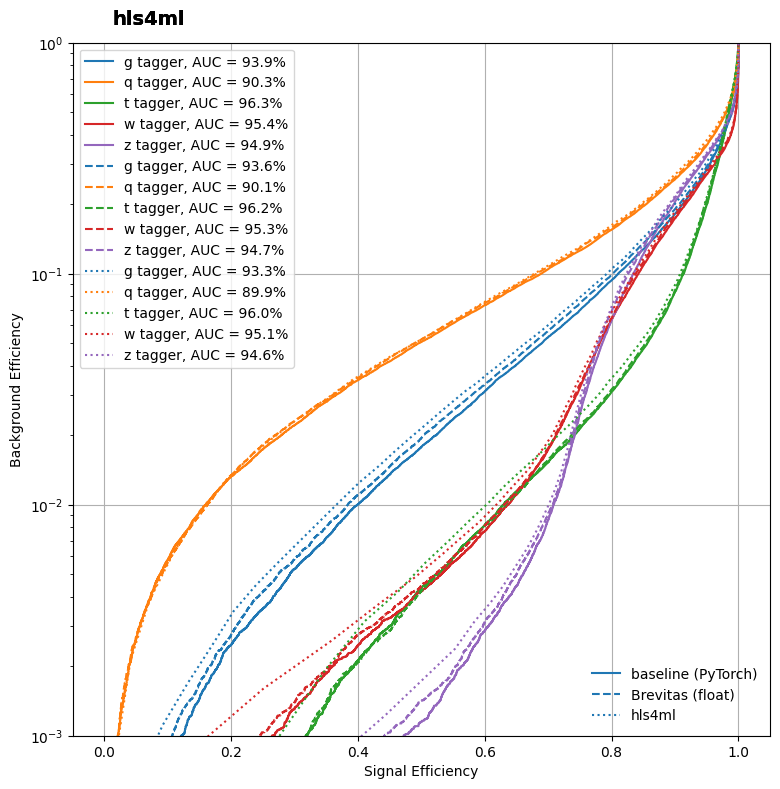

In [8]:
from sklearn.metrics import accuracy_score


# Load the baseline PyTorch model from Part 1b
class JetTagger(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(16, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 32)
        self.output = nn.Linear(32, 5)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return torch.softmax(self.output(x), dim=1)


model_ref = JetTagger()
model_ref.load_state_dict(torch.load('../models/pytorch_weights_part1.pt'))
model_ref.eval()
with torch.no_grad():
    y_ref = model_ref(torch.FloatTensor(X_test)).numpy()

print('Accuracy baseline (PyTorch):  {}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_ref, axis=1))))
print('Accuracy Brevitas (float):    {}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_brevitas, axis=1))))
print('Accuracy hls4ml:              {}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_ref, list(classes))
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_brevitas, list(classes), linestyle='--')
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_hls, list(classes), linestyle=':')

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--'), Line2D([0], [0], ls=':')]
leg = Legend(ax, lines, labels=['baseline (PyTorch)', 'Brevitas (float)', 'hls4ml'], loc='lower right', frameon=False)
ax.add_artist(leg)

## Synthesize

Now let's run Vitis HLS C-synthesis to get a first estimate of latency and resource usage.

**This can take several minutes.**


In [9]:
hls_model.build(csim=False)


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Thu Jul 16 09:22:25 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_brevitas_part2b/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_brevitas_part2b/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to the project
INFO: [HLS 200-1510]

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.645',
  'BestLatency': '22',
  'WorstLatency': '22',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '23',
  'DSP': '185',
  'FF': '20782',
  'LUT': '163700',
  'URAM': '0',
  'AvailableBRAM_18K': '4320',
  'AvailableDSP': '6840',
  'AvailableFF': '2364480',
  'AvailableLUT': '1182240',
  'AvailableURAM': '960'}}

In [10]:
hls4ml.report.read_vivado_report('../hls4ml_prjs/hls4ml_prj_brevitas_part2b')

Found 1 solution(s) in ../hls4ml_prjs/hls4ml_prj_brevitas_part2b/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Thu Jul 16 09:25:16 2026

* Version:        2024.2 (Build 5238294 on Nov  8 2024)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu200-fsgd2104-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.645 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +-----

Compare the DSP count above against the Part 1c baseline. With 6-bit quantization, every multiplication in this network is narrower than the ~10-bit threshold below which Vivado maps multiplications to LUT logic rather than DSP slices, significantly reducing the DSP usage.

## A note on HLS synthesis resource estimates

The resource numbers reported by Vitis HLS after HLS C-synthesis are **estimates** derived from the HLS's internal model and often do not truly reflect the final resource consumption of the model. These estimates **often overestimate** LUT consumption, sometimes by an order of magnitude.

For a more accurate picture of resource consumption, you should run **Vivado synthesis** (`vsynth`). This invokes the full Vivado synthesis flow on the generated RTL, producing estimates that are much closer to what you would see after implementation (place-and-route).

**This step can take 10–20 minutes.**

In [11]:
hls_model.build(reset=False, csim=False, vsynth=True)


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Thu Jul 16 09:25:23 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_brevitas_part2b/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_brevitas_part2b/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to the project
INFO: [HLS 200-1510]

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.645',
  'BestLatency': '22',
  'WorstLatency': '22',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '23',
  'DSP': '185',
  'FF': '20782',
  'LUT': '163700',
  'URAM': '0',
  'AvailableBRAM_18K': '4320',
  'AvailableDSP': '6840',
  'AvailableFF': '2364480',
  'AvailableLUT': '1182240',
  'AvailableURAM': '960'},
 'VivadoSynthReport': {'LUT': '62213',
  'FF': '16371',
  'BRAM_18K': '6.5',
  'URAM': '0',
  'DSP48E': '197'}}

In [12]:
hls4ml.report.read_vivado_report('../hls4ml_prjs/hls4ml_prj_brevitas_part2b')

Found 1 solution(s) in ../hls4ml_prjs/hls4ml_prj_brevitas_part2b/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Thu Jul 16 09:27:52 2026

* Version:        2024.2 (Build 5238294 on Nov  8 2024)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu200-fsgd2104-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.645 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +-----